# CNN Classifier

In [3]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import kagglehub
import matplotlib.pyplot as plt
from tqdm import tqdm

### Download Dataset
* link: https://www.kaggle.com/datasets/ankit1743/skyview-an-aerial-landscape-dataset

In [4]:
path = kagglehub.dataset_download("ankit1743/skyview-an-aerial-landscape-dataset")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Create Dataset loader

In [34]:
dataset = datasets.ImageFolder(
    root=f'{path}/Aerial_Landscapes',
    transform=transforms.ToTensor()
)

class_indices = {}

for i in range(len(dataset)):
    _,label = dataset[i]
    if label not in class_indices:
        class_indices[label] = []
    class_indices[label].append(i)

train_indices = []
val_indices = []
test_indices = []

for label in class_indices:
    indices = class_indices[label]
    
    train_split = int(len(indices) * 0.6)
    val_split = int(len(indices) * 0.8)
    test_split = int(len(indices) * 1.0)
    
    train_indices.extend(indices[:train_split])
    val_indices.extend(indices[train_split:val_split])
    test_indices.extend(indices[val_split:test_split])

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

### Dataloader

In [50]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Model

In [52]:
class ClassifierModel(nn.Module):
    def __init__(self, num_classes=15):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        
        self.flatten = nn.Flatten()
        
        # Fully connected layers
        self.fc1 = nn.Linear(256 * 8 * 8, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.dropout1 = nn.Dropout(p=0.5)
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn_fc2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(p=0.5)
        
        self.fc3 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.bn1(x)
        x = self.pool(x)  # 256x256 -> 128x128
        
        x = self.conv2(x)
        x = self.relu(x)
        x = self.bn2(x)
        x = self.pool(x)  # 128x128 -> 64x64
        
        x = self.conv3(x)
        x = self.relu(x)
        x = self.bn3(x)
        x = self.pool(x)  # 64x64 -> 32x32
        
        x = self.conv4(x)
        x = self.relu(x)
        x = self.bn4(x)
        x = self.pool(x)  # 32x32 -> 16x16
        
        x = self.conv5(x)
        x = self.relu(x)
        x = self.bn5(x)
        x = self.pool(x)  # 16x16 -> 8x8

        # Fully connected layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn_fc1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        x = self.bn_fc2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        
        return x

In [59]:
model = ClassifierModel().to(device)

lr = 0.0005
optimizer = torch.optim.Adam(params=model.parameters(),lr=lr, weight_decay=0.05)
loss_fn = nn.functional.cross_entropy

In [60]:
def plot_loss_curve(train_loss, val_loss):
    # Plot Train Loss
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label="Train Loss", color='blue')
    plt.title("Train Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Plot Validation Loss
    plt.figure(figsize=(10, 5))
    plt.plot(val_loss, label="Validation Loss", color='red')
    plt.title("Validation Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

### Train

Epoch 1 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.84batch/s]


Epoch 2 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.80batch/s]


Epoch 3 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.88batch/s]


Epoch 4 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.94batch/s]


Epoch 5 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.72batch/s]


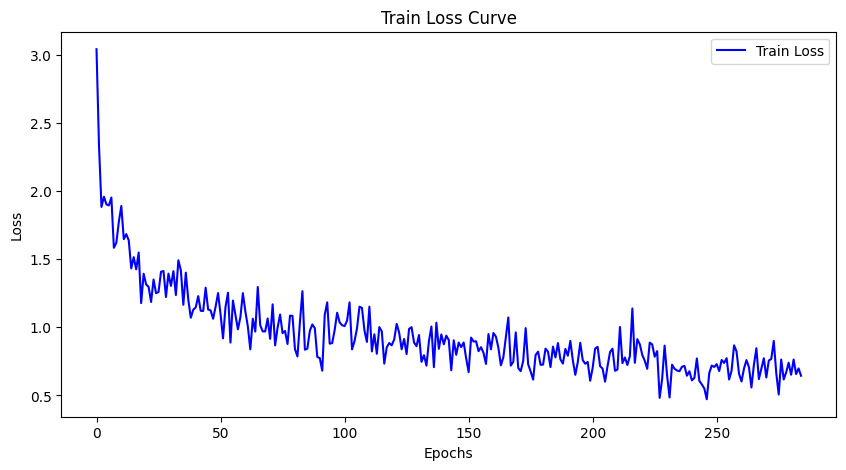

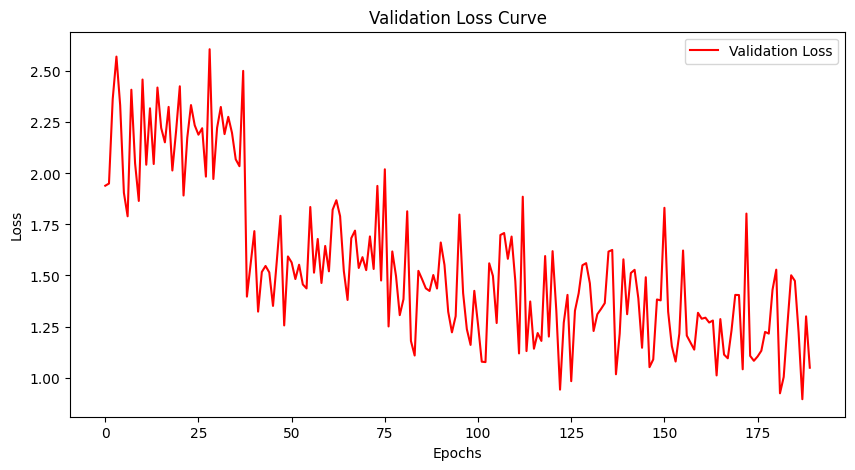

Epoch 6 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.09batch/s]


Epoch 7 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.90batch/s]


Epoch 8 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.01batch/s]


Epoch 9 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.85batch/s]


Epoch 10 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.81batch/s]


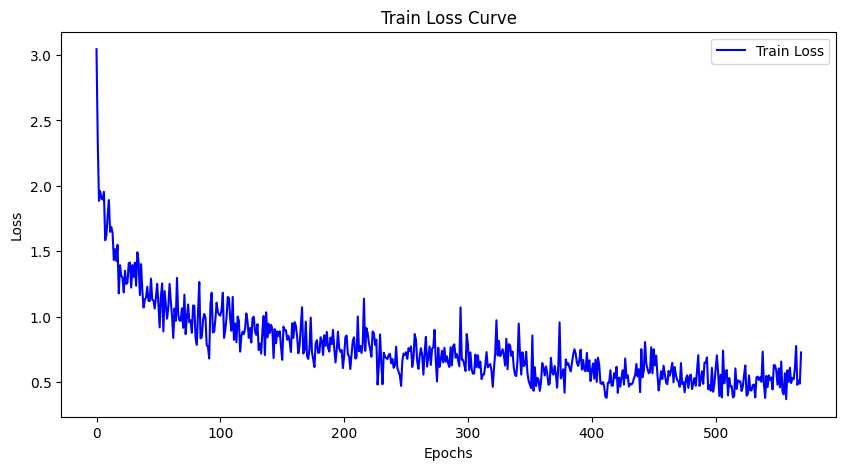

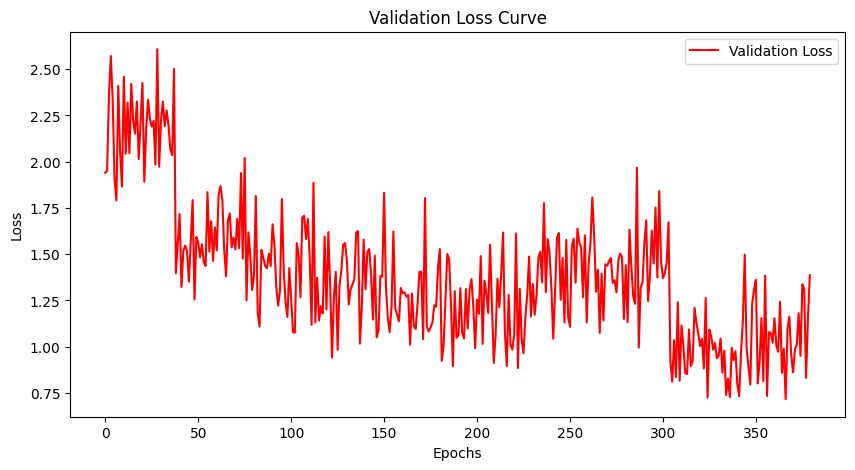

Epoch 11 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.32batch/s]


Epoch 12 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.32batch/s]


Epoch 13 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.87batch/s]


Epoch 14 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.03batch/s]


Epoch 15 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.40batch/s]


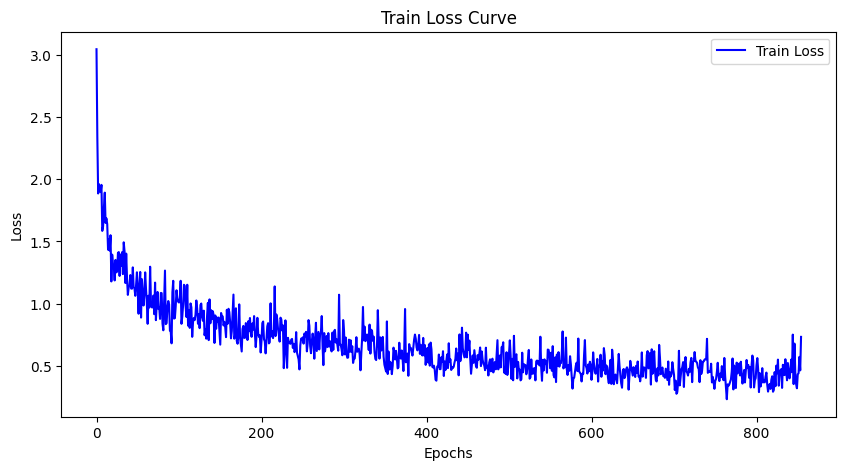

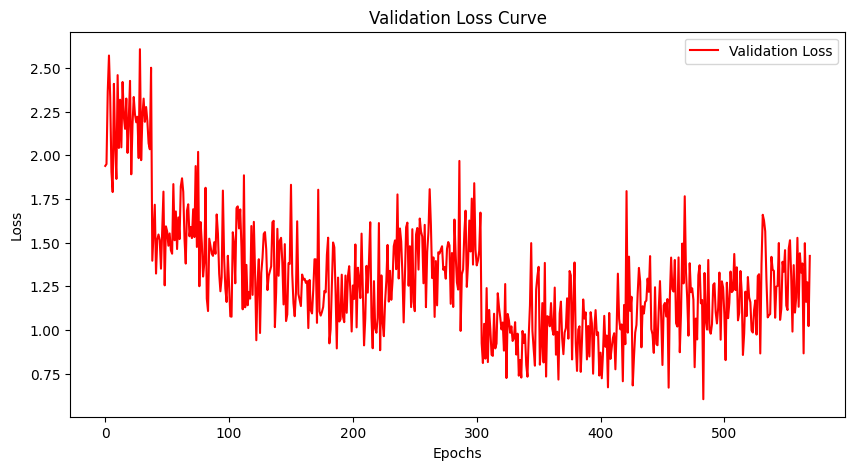

Epoch 16 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.67batch/s]


Epoch 17 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.99batch/s]


Epoch 18 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.38batch/s]


Epoch 19 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.40batch/s]


Epoch 20 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.39batch/s]


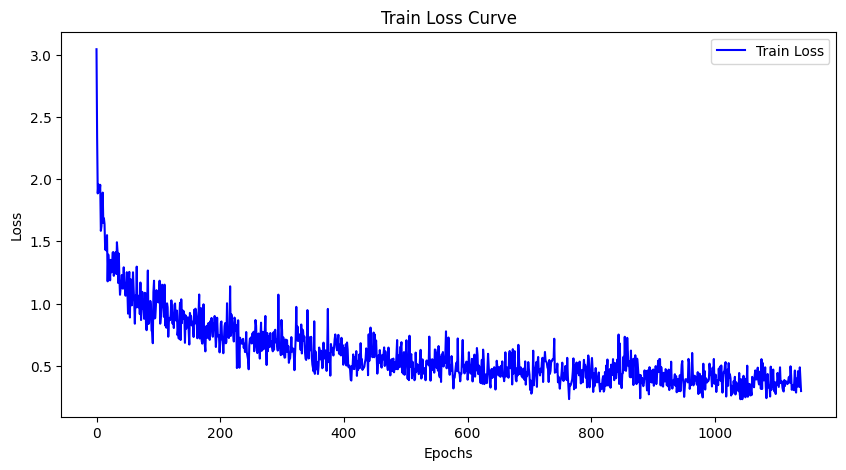

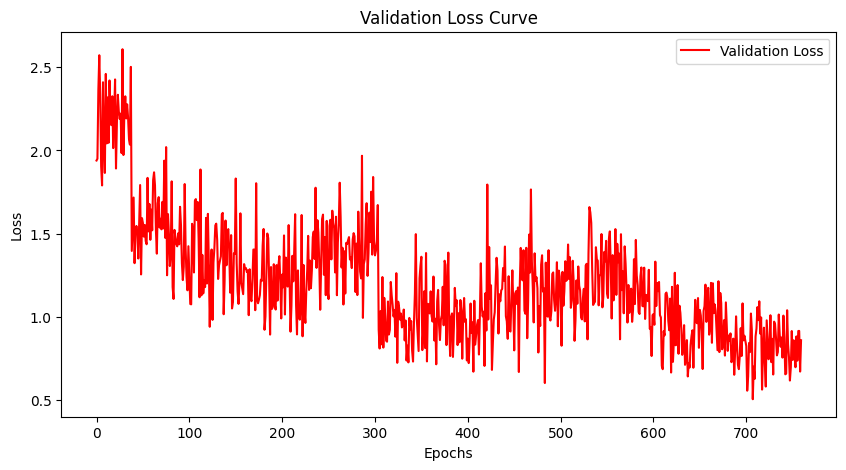

Epoch 21 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.99batch/s]


Epoch 22 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.92batch/s]


Epoch 23 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.08batch/s]


Epoch 24 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.31batch/s]


Epoch 25 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.46batch/s]


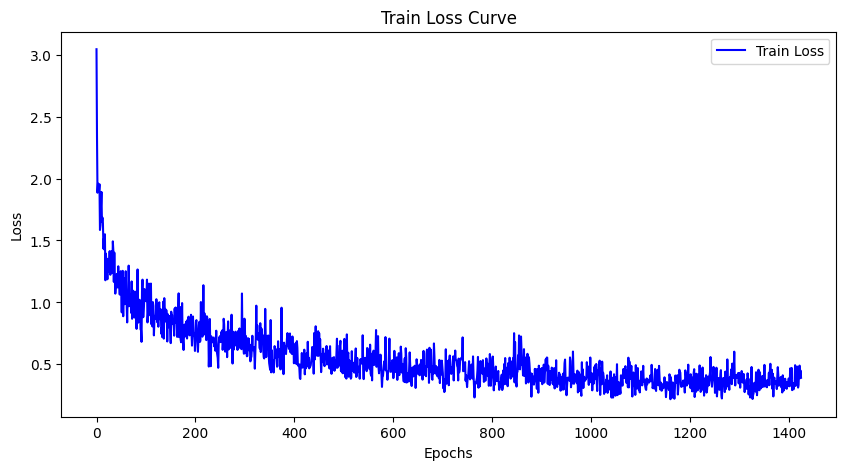

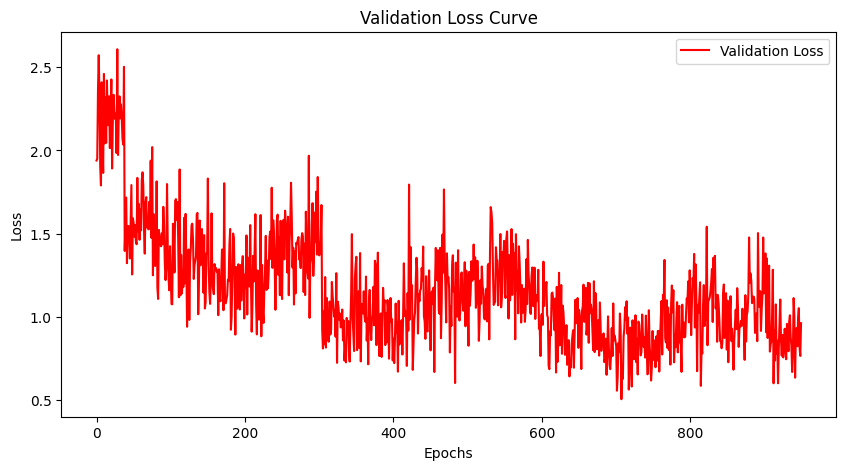

Epoch 26 running!


Validation: 100%|██████████| 38/38 [00:03<00:00, 10.27batch/s]


Epoch 27 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.97batch/s]


Epoch 28 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.60batch/s]


Epoch 29 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.95batch/s]


Epoch 30 running!


Validation: 100%|██████████| 38/38 [00:03<00:00,  9.76batch/s]


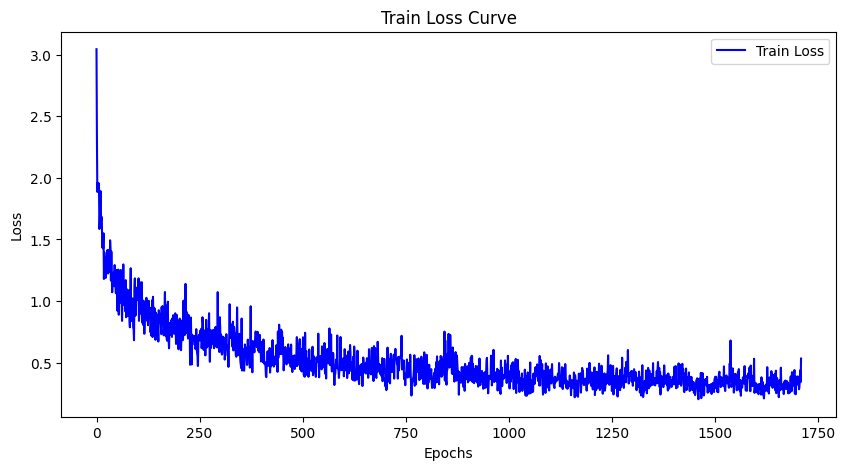

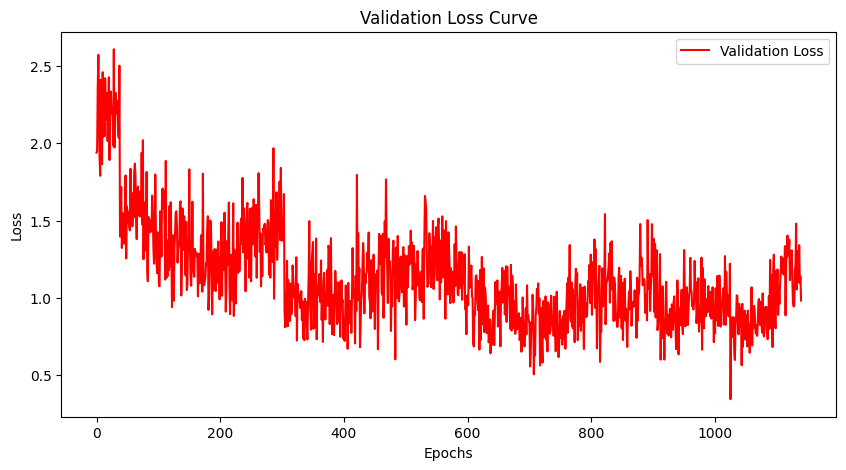

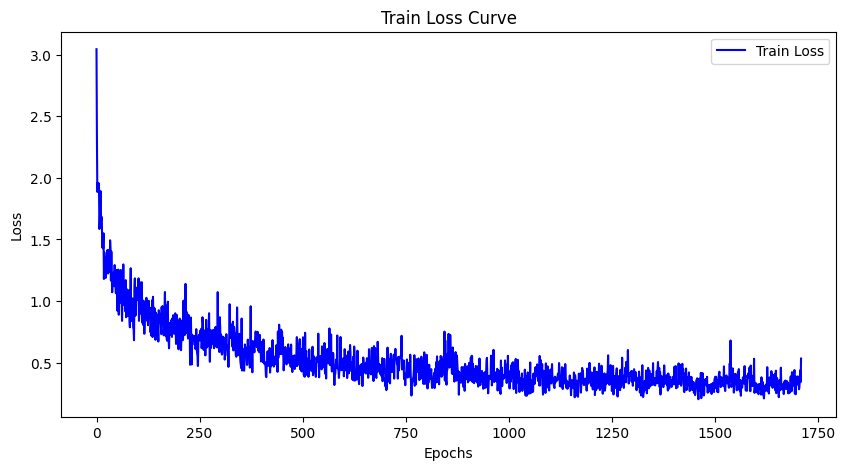

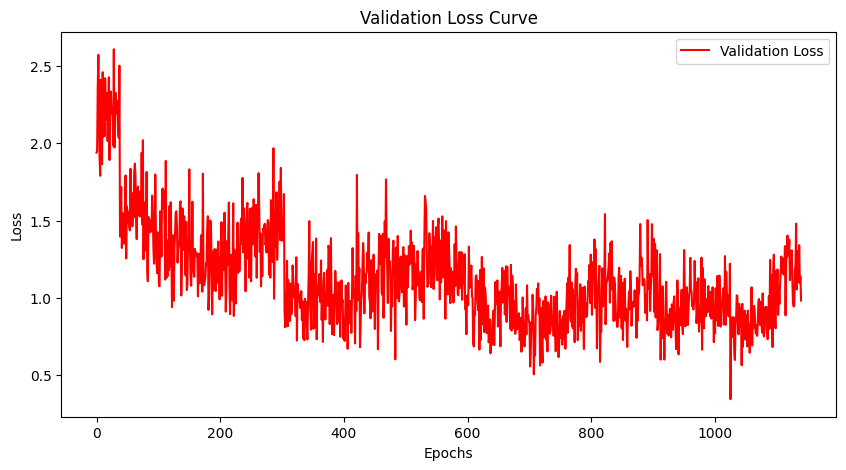

In [61]:
epochs = 30

train_loss = []
val_loss = []

for i in range(epochs):
    print(f"Epoch {i+1} running!")
    
    model.train()
    for X,t in tqdm(train_loader, unit="batch",desc="Training"):
        X,t = X.to(device),t.to(device)
        
        y = model(X)
        loss = loss_fn(y,t)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss.append(loss.item())
    
    model.eval()
    with torch.no_grad():
        for X,t in tqdm(val_loader, unit="batch",desc="Validation"):
            X,t = X.to(device),t.to(device)
            y = model(X)
            loss = loss_fn(y,t)
            val_loss.append(loss.item())
    
    if (i+1)%5 == 0:
        plot_loss_curve(train_loss, val_loss)

plot_loss_curve(train_loss, val_loss)

### Test

In [62]:
model.eval()

# Test accuracy calculation
test_correct = 0
test_total = 0
with torch.no_grad():
    for X, t in tqdm(test_loader, unit="batch", desc="Testing"):
        X, t = X.to(device), t.to(device)
        y = model(X)
        
        # Get predictions from the highest value
        predicted = torch.argmax(y, dim=1)
        
        # Count correct predictions
        test_correct += (predicted == t).sum().item()
        test_total += t.size(0)

test_accuracy = (test_correct / test_total) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Train accuracy calculation
train_correct = 0
train_total = 0
with torch.no_grad():
    for X, t in tqdm(train_loader, unit="batch", desc="Evaluating Train"):
        X, t = X.to(device), t.to(device)
        y = model(X)
        
        predicted = torch.argmax(y, dim=1)
        train_correct += (predicted == t).sum().item()
        train_total += t.size(0)

train_accuracy = (train_correct / train_total) * 100
print(f"Train Accuracy: {train_accuracy:.2f}%")
        

Testing: 100%|██████████| 2400/2400 [00:05<00:00, 449.87batch/s]


Test Accuracy: 69.54%


Evaluating Train: 100%|██████████| 57/57 [00:10<00:00,  5.24batch/s]

Train Accuracy: 81.89%
